<a href="https://colab.research.google.com/github/Gujeah/Modelling-Impaired-Memory-Retrieval-in-Dementia_Using-Hopfield-Networks/blob/main/Final_Final_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Hopfield using hierachy data for simulating semantic dementia

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **The hierachy**

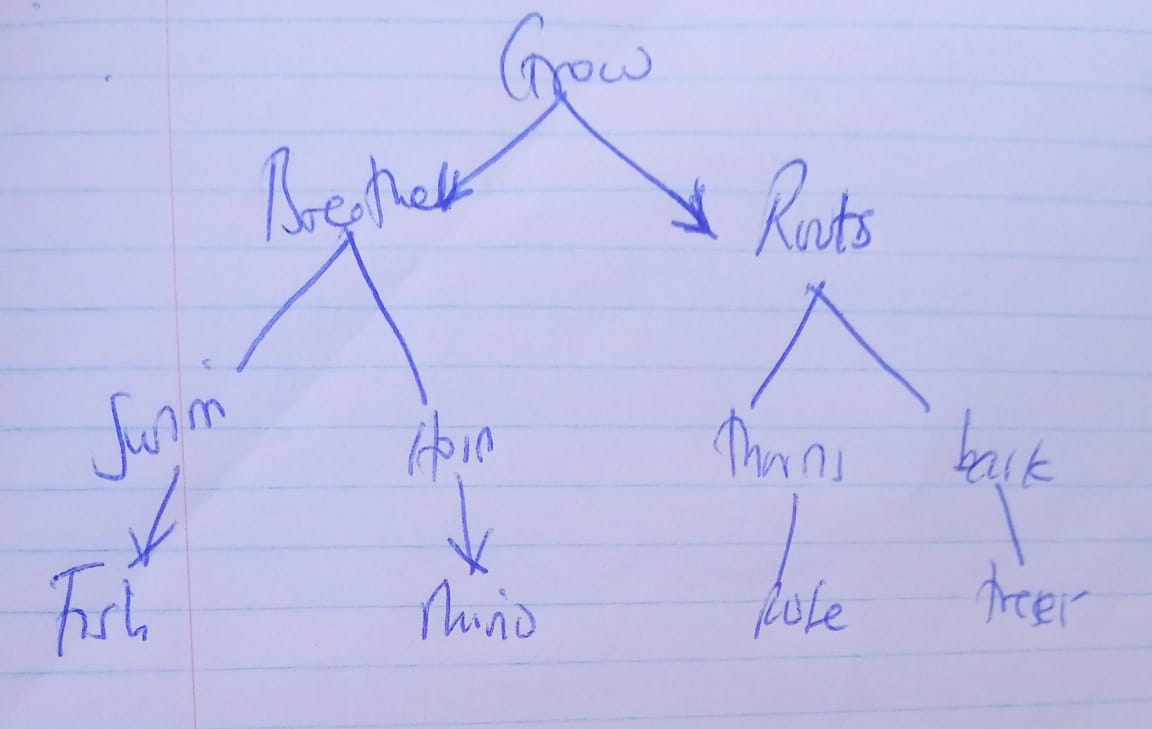

In [3]:

memories = np.zeros((11, 11), dtype=int)

#Level 0
memories[0] = [1,0,0,0,0,0,0,0,0,0,0]

#Level 1
memories[1] = [1,1,0,0,0,0,0,0,0,0,0]
memories[2] = [1,0,1,0,0,0,0,0,0,0,0]

#Level 2
memories[3] = [1,1,0,1,0,0,0,0,0,0,0]
memories[4] = [1,1,0,0,1,0,0,0,0,0,0]
memories[5] = [1,0,1,0,0,1,0,0,0,0,0]
memories[6] = [1,0,1,0,0,0,1,0,0,0,0]


memories[7]  = [1,1,0,1,0,0,0,1,0,0,0]
memories[8]  = [1,1,0,0,1,0,0,0,1,0,0]
memories[9]  = [1,0,1,0,0,1,0,0,0,1,0]
memories[10] = [1,0,1,0,0,0,1,0,0,0,1]

hopfield_memories = np.where(memories == 0, -1, 1)

print("Memory Matrix:")
print(hopfield_memories)

Memory Matrix:
[[ 1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [ 1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
 [ 1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1]
 [ 1  1 -1  1 -1 -1 -1 -1 -1 -1 -1]
 [ 1  1 -1 -1  1 -1 -1 -1 -1 -1 -1]
 [ 1 -1  1 -1 -1  1 -1 -1 -1 -1 -1]
 [ 1 -1  1 -1 -1 -1  1 -1 -1 -1 -1]
 [ 1  1 -1  1 -1 -1 -1  1 -1 -1 -1]
 [ 1  1 -1 -1  1 -1 -1 -1  1 -1 -1]
 [ 1 -1  1 -1 -1  1 -1 -1 -1  1 -1]
 [ 1 -1  1 -1 -1 -1  1 -1 -1 -1  1]]


In [ ]:

# class HopfieldNetwork:
#     def __init__(self, patterns):
#         self.n = patterns.shape[1]
#         self.p = patterns.shape[0]

#         ### weight initialization
#         self.W = np.zeros((self.n, self.n))

#         # Hebbian Learning (since it multiplies outer matrices)
#         for p in patterns:
#             self.W += np.outer(p, p)

#         # Normalize by N and set diagonals to 0 (no self-connections)- because its recuurecnt to we cant connect it again to itself
#         self.W /= self.n
#         np.fill_diagonal(self.W, 0)

#     def energy(self, state):
#         """Calculates the 'stress' or Energy of the current state."""
#         return -0.5 * np.dot(state, np.dot(self.W, state))

#     def update(self, state, steps=5):
#         """Retrieval to help the system of the hopfield find memory."""
#         new_state = np.copy(state)
#         for _ in range(steps):
#             for i in range(self.n):
#                 # The dot product of the i-th row of W and the state
#                 raw_input = np.dot(self.W[i], new_state)
#                 # Activation function: if > 0, state = 1; else -1
#                 new_state[i] = 1 if raw_input >= 0 else -1
#         return new_state

# net = HopfieldNetwork(hopfield_memories)

# print("Weight Matrix (Synapses) Shape:", net.W.shape)

In [4]:


class ModernHopfieldNetwork:
    def __init__(self, patterns):
        # We store the patterns directly as the 'memory bank'
        self.patterns = patterns.astype(float)
        self.p, self.n = patterns.shape

    def energy(self, state, beta=8.0):
        """
        Calculates the Log-Sum-Exp energy of the Modern Hopfield Network.
        Lower energy = more stable state.
        """
        # Similarity between current state and all stored patterns
        dot_products = np.dot(self.patterns, state)
        # The Modern Energy function: -log(sum(exp(beta * dot_products)))
        return - (1.0 / beta) * np.log(np.sum(np.exp(beta * dot_products)))

    def update(self, state, beta=10.0):
        """
        The Modern update rule (Softmax/Attention-based).beta: The 'Clarity' or 'Inverse Temperature' parameter. High beta  distinguish similar pattern
        """
        # 1. Measure similarity between input and all memories
        similarities = np.dot(self.patterns, state) #todo 1 add noise here and see if "fish" response changes from healthy (demenatia example)

        # 2. Apply Softmax to determine which memory the state 'looks' like
        # We subtract max for numerical stability
        exp_sim = np.exp(beta * (similarities - np.max(similarities)))
        attention_weights = exp_sim / np.sum(exp_sim) # todo 2 add noise here and see if "fish" response changes from health and dementia

        # 3. The new state is a weighted average of stored memories
        retrieved_continuous = np.dot(attention_weights, self.patterns)

        # 4. Mapping back to the original mapping we made
        return np.where(retrieved_continuous >= 0, 1, -1)

# function calling
modern_net = ModernHopfieldNetwork(hopfield_memories)

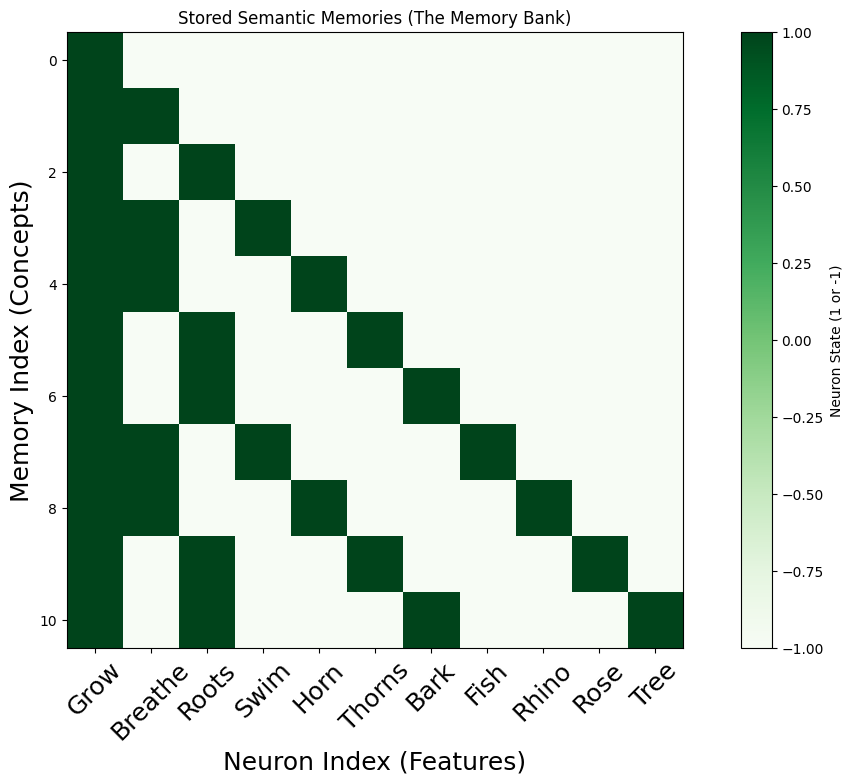

In [5]:


def plot_memory_bank(patterns):
    plt.figure(figsize=(15,8))
    plt.imshow(patterns, cmap='Greens', interpolation='nearest')
    plt.colorbar(label="Neuron State (1 or -1)")
    plt.title("Stored Semantic Memories (The Memory Bank)")
    plt.xlabel("Neuron Index (Features)", fontsize=18)
    plt.ylabel("Memory Index (Concepts)", fontsize=18)

    # hierarchy
    features = ["Grow", "Breathe", "Roots", "Swim", "Horn", "Thorns", "Bark", "Fish", "Rhino", "Rose", "Tree"]
    plt.xticks(range(11), features, rotation=45, fontsize=18)
    plt.savefig("memory bank")
    plt.show()


plot_memory_bank(hopfield_memories)

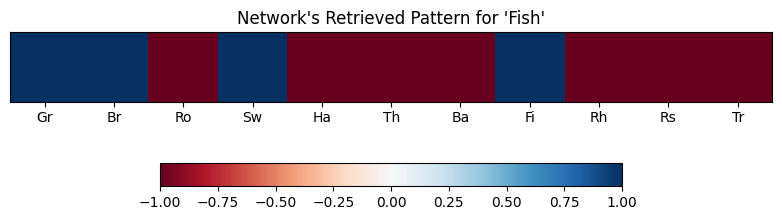

Retrieved Features:
[ON]  Grow
[ON]  Breathe
[OFF] Roots
[ON]  Swim
[OFF] Horn
[OFF] Thorns
[OFF] Bark
[ON]  Fish
[OFF] Rhino
[OFF] Rose
[OFF] Tree


In [6]:

target_index = 7
query_pattern = hopfield_memories[target_index].copy()

retrieved_pattern = modern_net.update(query_pattern, beta=23.0)
plt.figure(figsize=(10, 2))
plt.imshow(retrieved_pattern.reshape(1, -1), cmap='RdBu', vmin=-1, vmax=1)

# Labels"
features = ["Gr", "Br", "Ro", "Sw", "Ha", "Th", "Ba", "Fi", "Rh", "Rs", "Tr"]
plt.xticks(range(11), features)
plt.yticks([])
plt.title(f"Network's Retrieved Pattern for 'Fish'")
plt.colorbar(orientation='horizontal', pad=0.4)
plt.show()

# 4. Interpret the pattern as text
print("Retrieved Features:")
for i, feature in enumerate(["Grow", "Breathe", "Roots", "Swim", "Horn", "Thorns", "Bark", "Fish", "Rhino", "Rose", "Tree"]):
    if retrieved_pattern[i] == 1:
        print(f"[ON]  {feature}")
    else:
        print(f"[OFF] {feature}")

In [7]:
beta=10

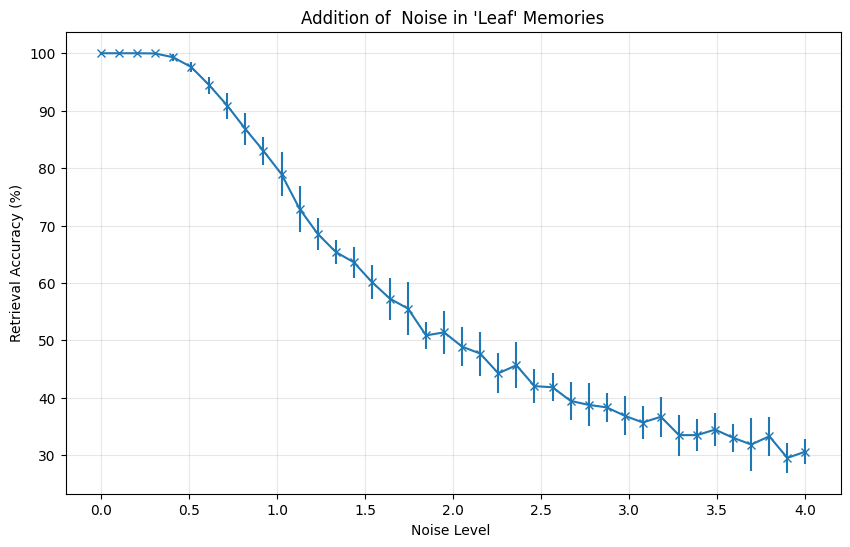

In [18]:

def add_noise(pattern, noise_level):
    """noise_level: float from 0 to 1 (percentage of bits to flip)"""
    #noisy_pattern = pattern.copy()
    #n_bits_to_flip = int(noise_level * len(pattern))
    #flip_indices = np.random.choice(len(pattern), n_bits_to_flip, replace=False)
    #noisy_pattern[flip_indices] *= -1
    noisy_pattern = pattern + np.random.normal(0, noise_level, pattern.shape)
    return noisy_pattern
    ### on noise I used gaussian noise instead of bits noise because memories dont just die at once it degrade slowly over time hence gaussian noise.

num_noise_levels = 40
leaf_indices = [7, 8, 9, 10]  # Fish, Rhino, Rose, Tree
noise_levels = np.linspace(0, 4, num_noise_levels) # 0% to 6x0% noise

plt.figure(figsize=(10, 6))
num_repeats = 15
accuracies = np.zeros([num_noise_levels, num_repeats])
for noise_ind, noise in enumerate(noise_levels):
  for repeat in range(num_repeats):
    correct = 0
    # Run 50 trials per leaf to get a stable average
    for _ in range(50):
        for idx in leaf_indices:
            target = hopfield_memories[idx]
            query = add_noise(target, noise)
            result = modern_net.update(query, beta)
            if np.array_equal(result, target):
                correct += 1
    accuracies[noise_ind, repeat] = ((correct / (len(leaf_indices) * 50)) * 100)

plt.errorbar(noise_levels, np.mean(accuracies, axis = 1), np.std(accuracies, axis = 1), marker='x')

plt.title("Addition of  Noise in 'Leaf' Memories")
plt.xlabel("Noise Level ")
plt.ylabel("Retrieval Accuracy (%)")
plt.grid(True, alpha=0.3)
plt.savefig("noise")
plt.show()

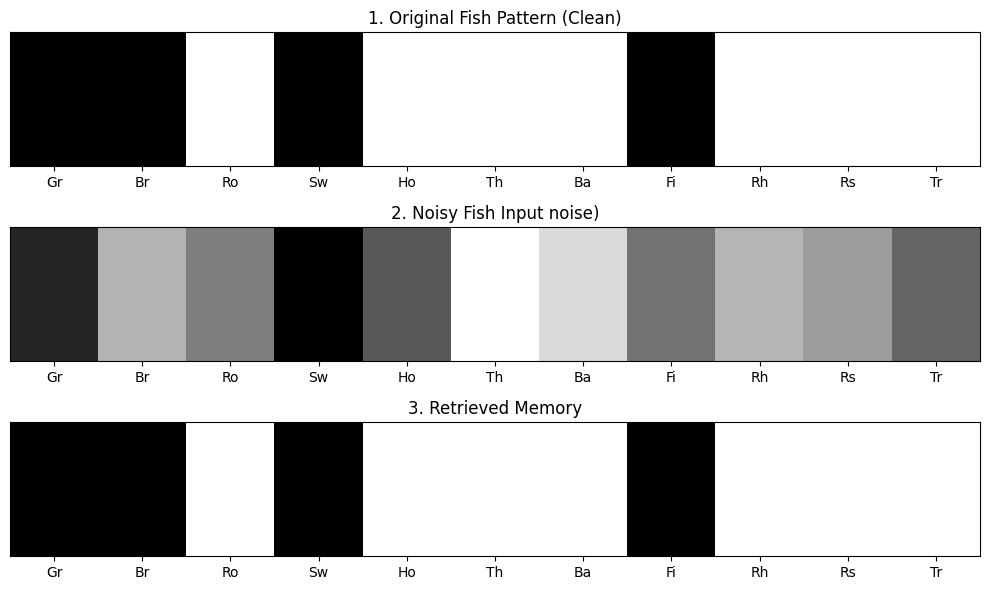

In [19]:

def visualize_fish_distortion(network, noise_level=0.5, beta_val=2.0):
    # original fish
    original_fish = hopfield_memories[7]

    # noise addition
    noisy_fish = add_noise(original_fish, noise_level)

    # 3. retrieving the memory
    retrieved_fish = network.update(noisy_fish, beta=beta_val)

    # 4. visualisation
    fig, axes = plt.subplots(3, 1, figsize=(10, 6))
    features = ["Gr", "Br", "Ro", "Sw", "Ho", "Th", "Ba", "Fi", "Rh", "Rs", "Tr"]

    patterns = [original_fish, noisy_fish, retrieved_fish]
    titles = ["1. Original Fish Pattern (Clean)",
              f"2. Noisy Fish Input noise)",
              f"3. Retrieved Memory"]
              # ({int(noise_level*100)}

    for i in range(3):
        axes[i].imshow(patterns[i].reshape(1, -1), cmap='binary', aspect='auto')
        axes[i].set_title(titles[i])
        axes[i].set_xticks(range(11))
        axes[i].set_xticklabels(features)
        axes[i].set_yticks([])

    plt.tight_layout()
    plt.savefig("pattern for noise of fish")
    plt.show()

visualize_fish_distortion(modern_net, noise_level=1.5, beta_val=1.5)

[Text(0, 0, 'Grow'),
 Text(0, 1, 'Breathe'),
 Text(0, 2, 'Root'),
 Text(0, 3, 'Swim'),
 Text(0, 4, 'Horn'),
 Text(0, 5, 'Thorn'),
 Text(0, 6, 'Bark'),
 Text(0, 7, 'Fish'),
 Text(0, 8, 'Rhino'),
 Text(0, 9, 'Rose'),
 Text(0, 10, 'Tree')]

<Figure size 1200x1200 with 0 Axes>

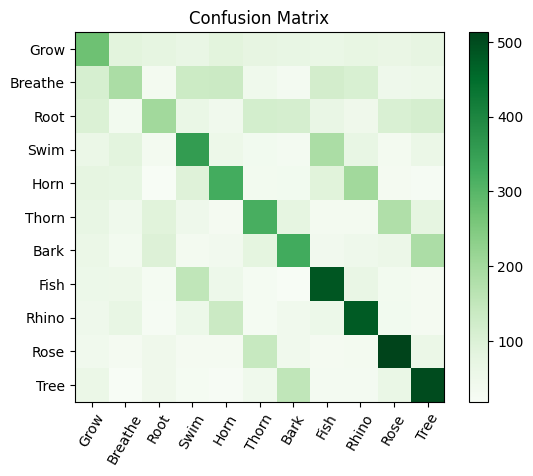

In [20]:
# go through each memory, add noise, measure what patterns get recalled, and make a confusion matrix
Confusion = np.zeros([11, 11])
features = ["Grow", "Breathe", "Root", "Swim", "Horn", "Thorn", "Bark", "Fish", "Rhino", "Rose", "Tree"]

for mu in range(11):
  for repeat in range(1000):
    noisy_pattern = add_noise(hopfield_memories[mu], 2.0)
    rec_pattern = modern_net.update(noisy_pattern, beta=beta)

    for nu in range(11):
      if np.array_equal(rec_pattern, hopfield_memories[nu]):
        Confusion[mu, nu] += 1

plt.figure(figsize = (12, 12))
fig, ax = plt.subplots(1,1)
plt.imshow(Confusion, cmap = 'Greens')
plt.colorbar()
plt.savefig('confusion_will.png')
plt.title('Confusion Matrix')
ax.set_xticks(np.arange(11))
ax.set_xticklabels(features, rotation = 60)
ax.set_yticks(np.arange(11))

ax.set_yticklabels(features)

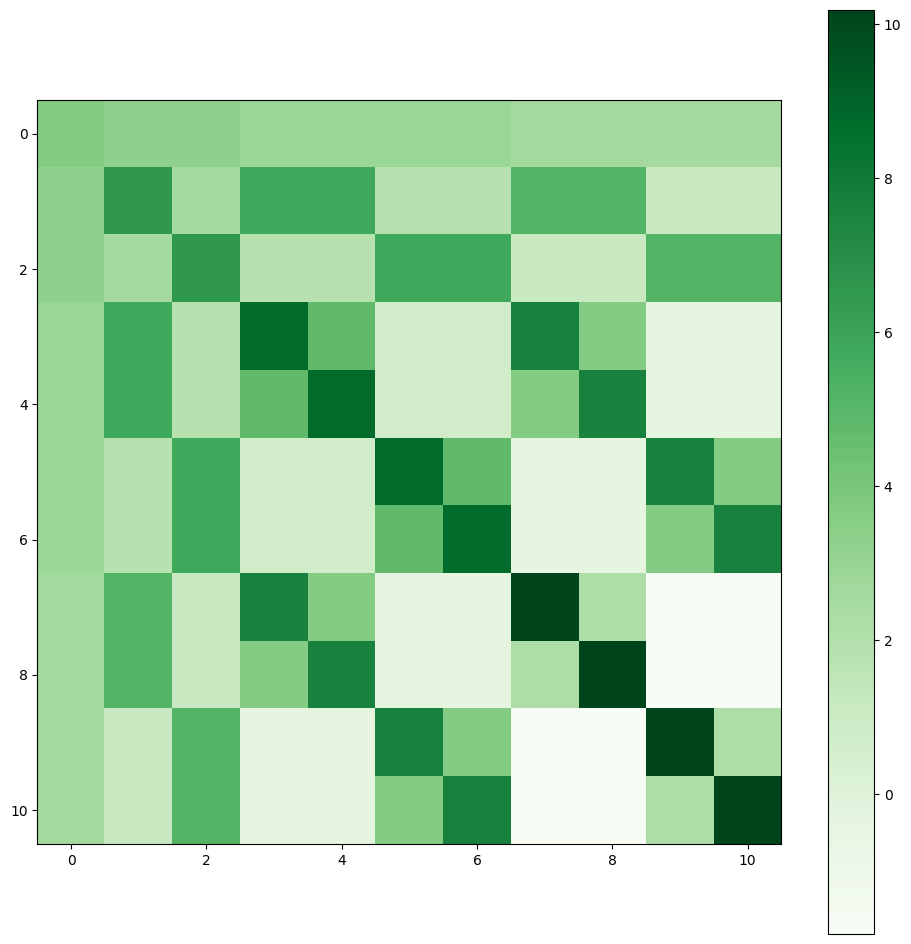

In [21]:
memories_dm = hopfield_memories - np.mean(hopfield_memories, axis = 1)[:,None]
plt.figure(figsize = (12, 12))
plt.imshow(memories_dm@memories_dm.T, cmap = 'Greens')
plt.colorbar()

Testing for the capacity of the pattern to see if the network will get distorted

In the Modern Hopfield model, Beta acts as the global synaptic "gain."

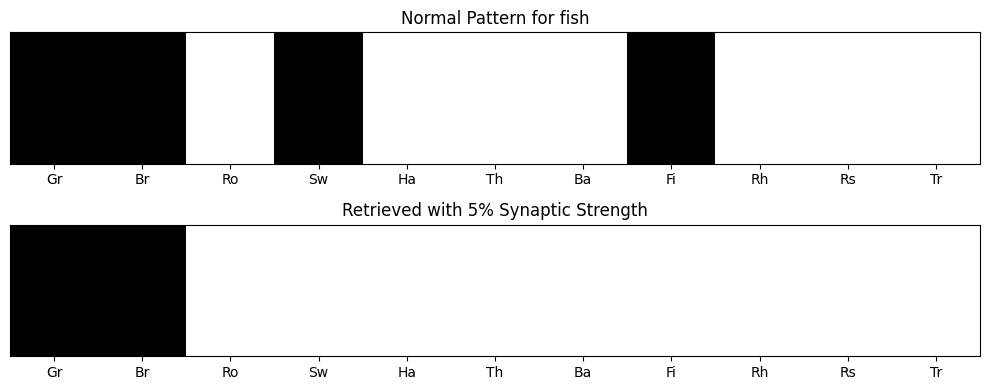

In [15]:

def compare_synaptic_strength(network, leaf_idx, strength_factor=0.5, beta_val=1.5):
    """
    leaf_idx: The index of the memory (7=Fish, 8=Rhino, etc.)
    strength_factor: 1.0 is healthy, 0.1 is severe synaptic loss.
    """
    healthy_patterns = network.patterns.copy()

    weakened_patterns = healthy_patterns * strength_factor

    # injecting the weak synapses into the network
    network.patterns = weakened_patterns

    # Attempt to retrieve the leaf (using a clean version to be fair)
    target_pattern = healthy_patterns[leaf_idx]
    retrieved = network.update(target_pattern, beta=beta_val)

    # Reseting the network back to healthy
    network.patterns = healthy_patterns

    features = ["Gr", "Br", "Ro", "Sw", "Ha", "Th", "Ba", "Fi", "Rh", "Rs", "Tr"]
    fig, axes = plt.subplots(2, 1, figsize=(10, 4))

    # Original
    axes[0].imshow(target_pattern.reshape(1, -1), cmap='binary', aspect='auto')
    axes[0].set_title(f"Normal Pattern for fish")

    # Plotting Retrieved from Weakened Synapses
    axes[1].imshow(retrieved.reshape(1, -1), cmap='binary', aspect='auto')
    axes[1].set_title(f"Retrieved with {int(strength_factor*100)}% Synaptic Strength")

    for ax in axes:
        ax.set_xticks(range(11))
        ax.set_xticklabels(features)
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

compare_synaptic_strength(modern_net, leaf_idx=7, strength_factor=0.05, beta_val=1.5)

In [ ]:
co